# Notebook 5: MuJoCo Tendon API — Spatial Tendons and Tension-Only Cables

## From Direct Actuation to Tendon-Driven Systems

In Notebooks 1–4 we applied forces and torques **directly** through motor actuators: `ctrl = force` in Newtons or `ctrl = torque` in Newton-metres, and MuJoCo applied that force straight to the joint. Real biomechanical and some robotic systems often transmit force through **tendons and cables** — think cable-driven robotic hands, exoskeletons, or the tendons connecting your finger muscles to your finger bones.

Tendons introduce two key complications that direct actuation does not have:

1. **Tension-only:** A cable can pull but never push. When slack, it exerts zero force.
2. **Routing geometry:** The cable path through via-points determines how forces are transmitted — get the path order wrong and the physics are wrong.

This notebook introduces MuJoCo's **spatial tendon API** on a simple system — a single pendulum with a cable attached to its tip — before you encounter the full capstone geometry (Notebook 6: block + pulley + lever).

**What you will learn:**
1. `data.ten_length[i]` — reading tendon length from the simulation state
2. Site-based routing — how the cable path is defined by an ordered list of sites
3. `springlength` deadband — MuJoCo's mechanism for tension-only cable behaviour
4. Analytical tension computation — why there is no `data.ten_force` field and what to use instead

**Why this system?** A pendulum with a cable is the smallest possible tendon-driven system: one body, one joint, one tendon, three sites. It isolates the API from geometry complexity.

## Setup

In [3]:
import os
import tempfile
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy    
import dms
%matplotlib inline
print(f"MuJoCo version: {mujoco.__version__}")

MuJoCo version: 3.6.0


## Theory: Spatial Tendons in MuJoCo

### What Is a Spatial Tendon?

A **spatial tendon** is a cable whose path is defined by an ordered list of **sites**. MuJoCo automatically computes the total cable length as the sum of straight-line distances between consecutive sites in world space:

$$L_{tendon} = \sum_{i=1}^{N-1} \|\mathbf{p}_{i+1} - \mathbf{p}_i\|$$

where $\mathbf{p}_i$ is the world-frame position of the $i$-th site along the cable path.

### The Cable Path — Site Order Matters

In the introductory model for this notebook, the cable routes through three sites in order:

```
anchor (ceiling) ──────── via (corner) ─────── tip (pendulum end)
     fixed worldbody site      fixed worldbody site      body-attached site
```

**MuJoCo reads the site list in the order you write it.** If you reverse the order, MuJoCo routes the cable backwards — the geometry changes and so does the force direction, with no compile-time error.

### Key API Field: `data.ten_length`

After each `mj_step`, MuJoCo updates `data.ten_length[i]` with the current geometric path length of tendon $i$. This is the primary observable for tendon-driven systems — it tells you how long the cable currently is, from which you can determine whether it is taut or slack.

### Tendon Stiffness and the `springlength` Deadband

A spatial tendon can have a passive spring along its length, set with the `stiffness` attribute. By default, this spring is **bidirectional** — it resists both lengthening and shortening, like a bungee cord. That is not a cable.

To make the tendon behave like a **tension-only cable**, MuJoCo uses the `springlength` attribute with **two values** forming a deadband:

```xml
<spatial stiffness="100" springlength="0 L_natural">
```

This means:
- For $L \leq L_{natural}$: the cable is slack, spring force = 0
- For $L > L_{natural}$: the cable is taut, spring force = $k \cdot (L - L_{natural})$

The lower bound `0` prevents compression (the cable cannot push). The upper bound `L_natural` is the rest length — the length at which the cable just becomes taut.

## Loading the Pendulum-Cable Model

### MJCF Design Choices

The model uses a minimal geometry to isolate the tendon API:

- **Pendulum body** (`rod`): a capsule geom extending in the +x direction from the origin (0, 0, 0.5), pinned to the world by a hinge joint rotating around the y-axis
- **Anchor site** (`anchor`): fixed to the ceiling at (0, 0, 1.0) — the topmost attachment point of the cable
- **Via site** (`via`): fixed at (0.5, 0, 1.0) — a fixed corner that redirects the cable from vertical to angled
- **Tip site** (`tip`): attached to the pendulum body at its free end (0.4, 0, 0 in body frame)

### Why a Via-Point?

Without the via-point, the cable would route straight from the ceiling anchor to the pendulum tip — a single straight segment. The via-point creates an L-shaped path, demonstrating that cables can be redirected through intermediate fixed points (like pulleys). In Notebook 6, the `corner_pulley` site plays the same role.

### Model File

The MJCF model is defined in `models/pendulum_cable_intro.xml`. Open the file to see the full XML with inline comments explaining each element. The `springlength` upper bound is pre-set to the correct natural length (1.0099 m) — we verify this measurement in the next cell.

In [6]:
# Load MJCF model from file
model_path = dms.get_asset_path('mujoco_models/pendulum_cable.xml')
model = mujoco.MjModel.from_xml_path(str(model_path))
data  = mujoco.MjData(model)

print(f"Model loaded from: {model_path}")
print(f"  Tendons (ntendon): {model.ntendon}")
print(f"  Tendon name:       {mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_TENDON, 0)}")

Model loaded from: C:\git\dynamics_of_mechanical_systems\src\dms\assets\mujoco_models\pendulum_cable.xml
  Tendons (ntendon): 1
  Tendon name:       intro_cable


## Verifying the Natural Length

### Why the Natural Length Matters

The `springlength` upper bound must match the **actual geometric path length** at the default configuration. If it is wrong:
- Too small: the cable is always taut (even at rest), pulling the pendulum constantly
- Too large: the cable never becomes taut when stretched, providing no force

### Verification Procedure

The model file `models/pendulum_cable.xml` already has the correct `springlength="0 1.0099"`. We verify this by:

1. Calling `mujoco.mj_forward(model, data)` — this runs the full forward pass, computing site positions **and** updating `data.ten_length`
2. Reading `data.ten_length[0]` — MuJoCo computes the geometric path length through the three sites at the default configuration
3. Comparing to the value in the XML to confirm they match

**Important:** `mj_kinematics` alone does **not** update `data.ten_length` — it only propagates body and site positions in world frame. You must call `mj_forward` (or run `mj_step`) to get a valid `ten_length` reading.

The measured value is the **natural length** $L_{natural}$ — the cable length when the pendulum is at $\theta = 0$ (rod pointing in +x direction).

In [9]:
# Propagate default configuration to world-frame positions
# mj_forward runs the full forward pass: computes site positions AND updates ten_length
# (mj_kinematics alone does not update data.ten_length)
mujoco.mj_forward(model, data)  # required to get valid ten_length reading

# Read the tendon length at the default pose (theta=0, rod pointing in +x)
L_natural = float(data.ten_length[0])
print(f"Model file: {model_path}")
print(f"Tendon natural length at default configuration: {L_natural:.4f} m")
print()
print("Geometric breakdown (site world positions at theta=0):")
print(f"  anchor  = {data.site_xpos[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'anchor')]}")
print(f"  via     = {data.site_xpos[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'via')]}")
print(f"  tip     = {data.site_xpos[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'tip')]}")

# Verify: compute manually
s_anchor = data.site_xpos[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'anchor')].copy()
s_via    = data.site_xpos[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'via')].copy()
s_tip    = data.site_xpos[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'tip')].copy()
L_manual = np.linalg.norm(s_via - s_anchor) + np.linalg.norm(s_tip - s_via)
print(f"\nManual path length check: {L_manual:.4f} m  (matches data.ten_length: {abs(L_manual - L_natural) < 1e-6})")

# Verify the springlength in the XML matches the measured natural length
springlength_xml = 1.0099  # from models/pendulum_cable_intro.xml
print(f"\nspringlength upper bound in XML: {springlength_xml}")
print(f"Measured natural length:          {L_natural:.4f}")
print(f"Match (within 0.001 m):           {abs(L_natural - springlength_xml) < 0.001}")
print("\nThe cable will be slack (zero force) at the default pose and taut when stretched.")

Model file: C:\git\dynamics_of_mechanical_systems\src\dms\assets\mujoco_models\pendulum_cable.xml
Tendon natural length at default configuration: 1.0099 m

Geometric breakdown (site world positions at theta=0):
  anchor  = [0. 0. 1.]
  via     = [0.5 0.  1. ]
  tip     = [0.4 0.  0.5]

Manual path length check: 1.0099 m  (matches data.ten_length: True)

springlength upper bound in XML: 1.0099
Measured natural length:          1.0099
Match (within 0.001 m):           True

The cable will be slack (zero force) at the default pose and taut when stretched.


## Experiment 1: Tendon Length During Free Swing

### Setup

We start the pendulum at $\theta \approx +0.9$ rad (rod tilted upward, about 52 degrees above horizontal)
and release it under gravity. No control input.

### What to Expect

The cable geometry for this model creates an interesting pattern:

- **Above horizontal (negative $\theta$):** The tip is above the pivot and close to the via site,
  making the cable path **long** — cable is slack.
- **Below horizontal ($\theta \approx 0$ to $-30$ deg):** The tip swings below the pivot stretching the tendon. The cable goes taut. 

The key observation: `data.ten_length` changes continuously with configuration,
and the cable alternates between slack and taut regions as the pendulum swings.

In [16]:
# --- Experiment 1: Free swing from theta=+0.9 rad (rod tilted upward) ---
# Starting above horizontal so the cable begins slack (L < L_natural).
# Gravity swings the rod downward, demonstrating the transition from
# slack -> taut as the tip moves away from the via-point.

# Get joint index (used for qpos assignment and recording)
hinge_qpos_idx = model.joint("hinge").qposadr[0]  # index into data.qpos

# Set initial angle: +0.9 rad tilts rod upward, shortening the cable path
mujoco.mj_resetData(model, data)
data.qpos[hinge_qpos_idx] = 0.9  # above horizontal -> cable is slack here
mujoco.mj_forward(model, data)   # compute initial state (including ten_length)
print(f"Initial state: theta={data.qpos[hinge_qpos_idx]:.3f} rad, "
      f"ten_length={data.ten_length[0]:.4f} m  (vs L_natural={L_natural:.4f} m)")
slack_or_taut = "SLACK" if data.ten_length[0] < L_natural else "TAUT"
print(f"Cable at start: {slack_or_taut}")

# Simulation parameters
sim_duration = 3.0           # 3 seconds of free swing
dt           = model.opt.timestep
n_steps      = int(sim_duration / dt)

# Pre-allocate recording arrays (record-then-plot convention from NB1-NB4)
t_hist1      = np.zeros(n_steps)  # time
theta_hist1  = np.zeros(n_steps)  # pendulum angle (rad)
tenlen_hist1 = np.zeros(n_steps)  # tendon length (m)

# Simulate
frames = [] 
renderer = mujoco.Renderer(model)
cam=dms.mujoco.make_camera(model)
for i in range(n_steps):
    t_hist1[i]      = data.time
    theta_hist1[i]  = data.qpos[hinge_qpos_idx].copy()
    tenlen_hist1[i] = data.ten_length[0].copy()  # copy() for safety across mj_step
    mujoco.mj_step(model, data)
    renderer.update_scene(data, camera=cam)
    frames.append(renderer.render().copy())

renderer.close()
mediapy.show_video(frames, fps=int(1/dt))


Initial state: theta=0.900 rad, ten_length=1.3513 m  (vs L_natural=1.0099 m)
Cable at start: TAUT


This browser does not support the video tag.


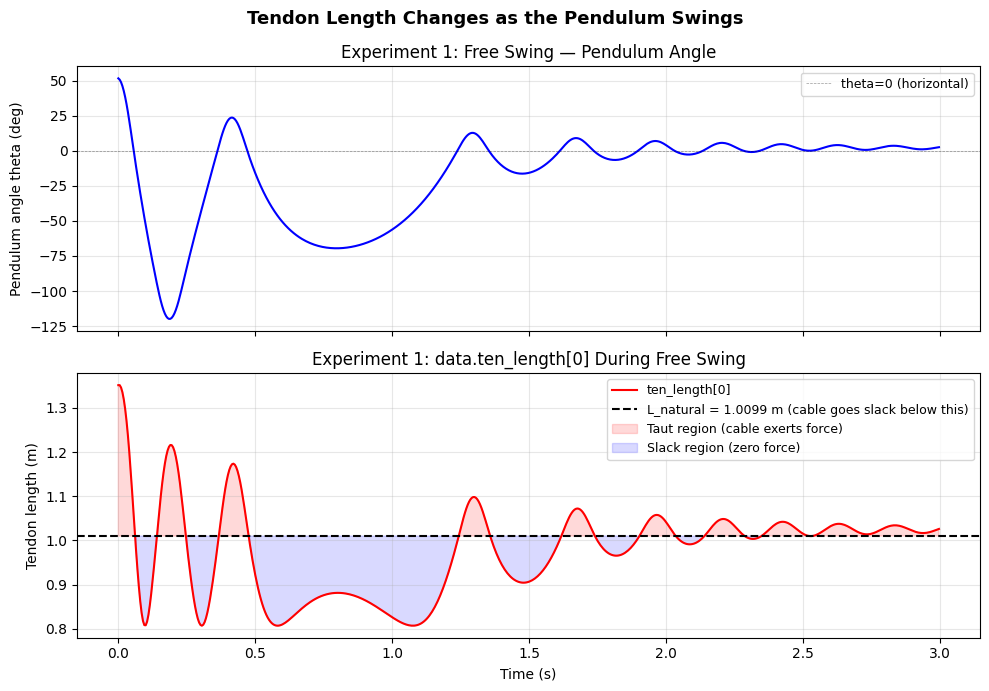

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- Top: Pendulum angle ---
ax = axes[0]
ax.plot(t_hist1, np.degrees(theta_hist1), 'b-', lw=1.5)
ax.axhline(0, color='k', lw=0.5, linestyle='--', alpha=0.4, label='theta=0 (horizontal)')
ax.set_ylabel('Pendulum angle theta (deg)')
ax.set_title('Experiment 1: Free Swing — Pendulum Angle')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Bottom: Tendon length ---
ax = axes[1]
ax.plot(t_hist1, tenlen_hist1, 'r-', lw=1.5, label='ten_length[0]')
ax.axhline(L_natural, color='k', lw=1.5, linestyle='--',
           label=f'L_natural = {L_natural:.4f} m (cable goes slack below this)')
ax.fill_between(t_hist1, tenlen_hist1, L_natural,
                where=(tenlen_hist1 > L_natural), alpha=0.15, color='red',
                label='Taut region (cable exerts force)')
ax.fill_between(t_hist1, tenlen_hist1, L_natural,
                where=(tenlen_hist1 <= L_natural), alpha=0.15, color='blue',
                label='Slack region (zero force)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Tendon length (m)')
ax.set_title('Experiment 1: data.ten_length[0] During Free Swing')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Tendon Length Changes as the Pendulum Swings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Reading the plots:**

 - As the pendulum swings downward to positive angles, data.ten_length[0] rises above $L_{natural}$ —
   the cable becomes taut (red region) and exerts a restoring force.
  - As the pendulum swings back through zero toward negative angles, the cable path shortens below
  $L_{natural}$ — the cable goes slack (blue region) and exerts no force.
  - The cable exerts force only during the red (taut) periods. During the blue (slack) periods, it
  acts as if it does not exist — the pendulum swings freely under gravity.

  **Key takeaway**: Reading `data.ten_length[0]` after each mj_step gives you the instantaneous cable path
  length. You determine whether the cable is slack or taut by comparing to $L_{natural}$. MuJoCo
  handles the force computation internally based on the springlength deadband you specified.


## Theory: Tension-Only Behaviour and the `springlength` Deadband

### The Cable Force Law

With `springlength="0 L_natural"`, the cable tension follows a **half-rectified** spring law:

$$F_{cable} = k \cdot \max\left(0,\; L - L_{natural}\right)$$

where:
- $k$ is the tendon `stiffness` (N/m)
- $L = $ `data.ten_length[0]` is the current cable length
- $L_{natural}$ is the upper bound of the `springlength` deadband

The $\max(0, \cdot)$ is the key: the cable **never generates negative (compressive) force**. When $L < L_{natural}$, the cable is slack and contributes nothing.

### Contrast with a Bidirectional Spring

Without the `springlength` deadband, the default tendon stiffness is **bidirectional**:

$$F_{spring} = k \cdot (L - L_0) \quad \text{(can be negative!)}$$

A negative spring force means the tendon **pushes** the pendulum back when it tries to move closer to the anchor. This is not physical for a cable — cables go slack, they do not push. The `springlength` deadband is MuJoCo's mechanism to model tension-only elements correctly.

### Important: There Is No `data.ten_force` Field

> **Anti-pattern warning:** MuJoCo's `mjData` structure does **not** have a `ten_force` field. Code like `data.ten_force[0]` raises `AttributeError` in MuJoCo 3.6.0. The `mjdata.h` header confirms this field does not exist.

> There is a `tendonactuatorfrc` sensor, but it measures **actuator-applied forces** on the tendon (from a `<motor>` or `<general>` actuator whose transmission is the tendon) — not passive spring tension. For a cable with no tendon actuator, `tendonactuatorfrc` reads zero.

> **Correct approach:** Compute tension analytically from `data.ten_length`, the stiffness, and the springlength upper bound, as shown in Experiment 2 below.

## Experiment 2: Compute Tension - Demonstration

We repeat the free swing (starting at $theta = 0.9$ rad, cable stretched initially)
and compute the cable tension analytically at each step:

$$T(t) = k \cdot \max\left(0,\; L(t) - L_{natural}\right)$$

The three-subplot figure shows: (1) pendulum angle, (2) cable length with $L_{natural}$ marked,
(3) cable tension — demonstrating that tension is **exactly zero** whenever the cable
is shorter than $L_{natural}$, and positive only when the cable is stretched.


In [19]:
# --- Experiment 2: Tension-only demonstration ---

STIFFNESS = 100.0   # must match MJCF stiffness attribute

def cable_tension(ten_length_val):
    """Compute passive cable tension analytically.

    Args:
        ten_length_val: current tendon length from data.ten_length[0]
    Returns:
        Tension in Newtons. Zero when cable is slack (L <= L_natural).

    Note: there is no data.ten_force field in MuJoCo 3.6.0.
    Tension must be computed analytically from data.ten_length.
    """
    stretch = ten_length_val - L_natural
    return STIFFNESS * max(0.0, stretch)


# Reset and simulate (same starting condition as Experiment 1: theta=+0.9 rad)
mujoco.mj_resetData(model, data)
data.qpos[hinge_qpos_idx] = 0.9  # start with cable slack (above horizontal)
mujoco.mj_forward(model, data)

sim_duration2 = 4.0
n_steps2      = int(sim_duration2 / dt)

t_hist2       = np.zeros(n_steps2)
theta_hist2   = np.zeros(n_steps2)
tenlen_hist2  = np.zeros(n_steps2)
tension_hist2 = np.zeros(n_steps2)

frames= []
renderer= mujoco.Renderer(model)
cam = dms.mujoco.make_camera(model)
for i in range(n_steps2):
    t_hist2[i]       = data.time
    theta_hist2[i]   = data.qpos[hinge_qpos_idx].copy()
    L_current        = float(data.ten_length[0].copy())
    tenlen_hist2[i]  = L_current
    tension_hist2[i] = cable_tension(L_current)
    mujoco.mj_step(model, data)
    renderer.update_scene(data, camera=cam)
    frames.append(renderer.render().copy())
renderer.close()
mediapy.show_video(frames, fps=int(1/dt))

print(f"Experiment 2 complete: {sim_duration2} s")
n_taut  = np.sum(tension_hist2 > 0)
n_slack = np.sum(tension_hist2 == 0.0)
print(f"  Taut steps:  {n_taut}  ({100.0*n_taut/n_steps2:.1f}% of simulation)")
print(f"  Slack steps: {n_slack}  ({100.0*n_slack/n_steps2:.1f}% of simulation)")
print(f"  Max tension: {tension_hist2.max():.2f} N")

This browser does not support the video tag.


Experiment 2 complete: 4.0 s
  Taut steps:  487  (60.9% of simulation)
  Slack steps: 313  (39.1% of simulation)
  Max tension: 34.14 N


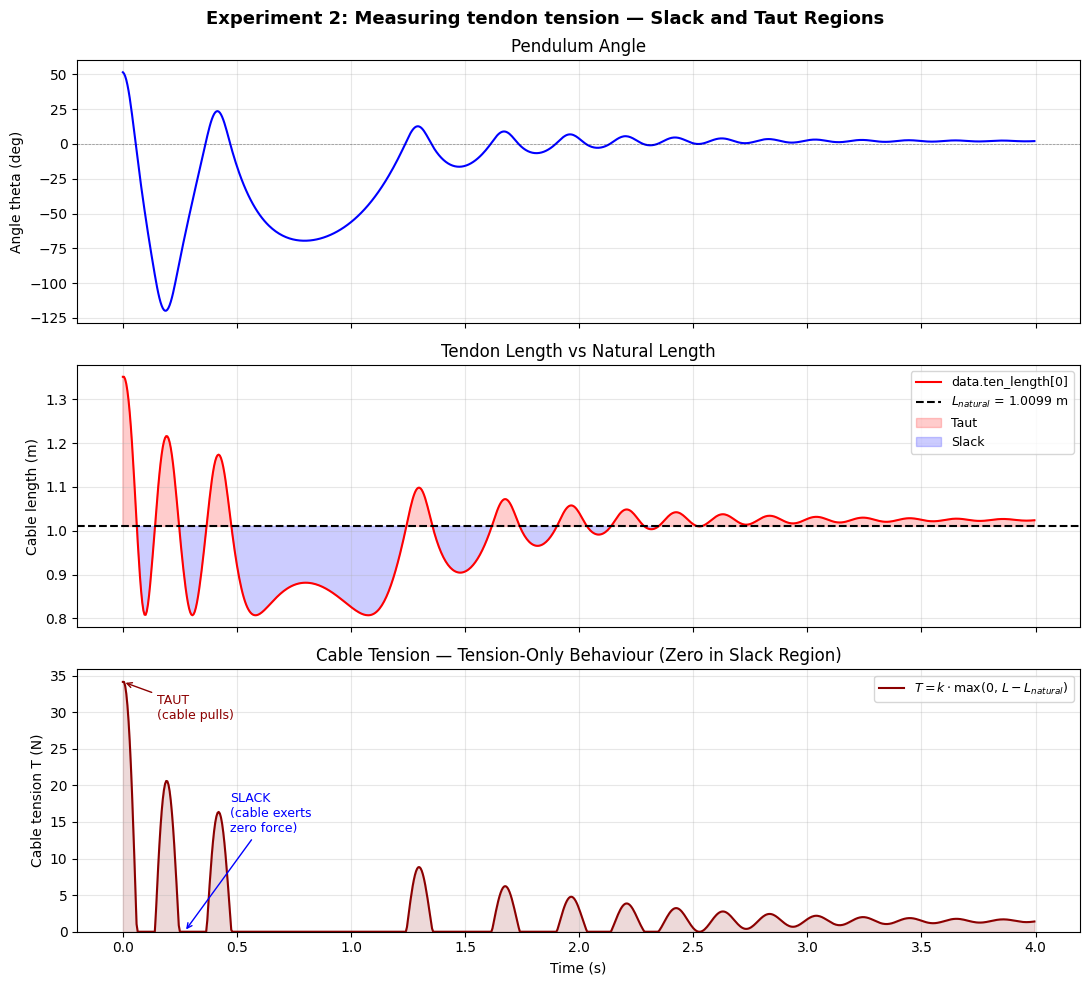

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

# --- Top: Pendulum angle ---
ax = axes[0]
ax.plot(t_hist2, np.degrees(theta_hist2), 'b-', lw=1.5)
ax.axhline(0, color='k', lw=0.5, linestyle='--', alpha=0.4)
ax.set_ylabel('Angle theta (deg)')
ax.set_title('Pendulum Angle')
ax.grid(True, alpha=0.3)

# --- Middle: Tendon length with L_natural marked ---
ax = axes[1]
ax.plot(t_hist2, tenlen_hist2, 'r-', lw=1.5, label='data.ten_length[0]')
ax.axhline(L_natural, color='k', lw=1.5, linestyle='--',
           label=f'$L_{{natural}}$ = {L_natural:.4f} m')
ax.fill_between(t_hist2, tenlen_hist2, L_natural,
                where=(tenlen_hist2 > L_natural), alpha=0.2, color='red', label='Taut')
ax.fill_between(t_hist2, tenlen_hist2, L_natural,
                where=(tenlen_hist2 <= L_natural), alpha=0.2, color='blue', label='Slack')
ax.set_ylabel('Cable length (m)')
ax.set_title('Tendon Length vs Natural Length')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Bottom: Cable tension ---
ax = axes[2]
ax.plot(t_hist2, tension_hist2, color='darkred', lw=1.5,
        label=r'$T = k \cdot \max(0,\, L - L_{natural})$')
ax.fill_between(t_hist2, tension_hist2, 0, alpha=0.15, color='darkred')

# Annotate slack and taut regions on the tension plot
# Find first extended slack and taut periods for annotation arrows
taut_mask  = tension_hist2 > 0
slack_mask = ~taut_mask

# Find a good slack annotation point (early in simulation)
first_slack_idx = np.where(slack_mask)[0]
if len(first_slack_idx) > 50:
    slack_t = t_hist2[first_slack_idx[20]]
    ax.annotate('SLACK\n(cable exerts\nzero force)',
                xy=(slack_t, 0),
                xytext=(slack_t + 0.2, tension_hist2.max() * 0.4),
                arrowprops=dict(arrowstyle='->', color='blue'),
                color='blue', fontsize=9)

# Find a good taut annotation point
first_taut_idx = np.where(taut_mask)[0]
if len(first_taut_idx) > 10:
    peak_idx = np.argmax(tension_hist2)
    ax.annotate('TAUT\n(cable pulls)',
                xy=(t_hist2[peak_idx], tension_hist2[peak_idx]),
                xytext=(t_hist2[peak_idx] + 0.15, tension_hist2[peak_idx] * 0.85),
                arrowprops=dict(arrowstyle='->', color='darkred'),
                color='darkred', fontsize=9)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Cable tension T (N)')
ax.set_title('Cable Tension — Tension-Only Behaviour (Zero in Slack Region)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # tension is non-negative

plt.suptitle('Experiment 2: Measuring tendon tension — Slack and Taut Regions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Key observation:** The cable tension plot has an exact floor at zero — it never goes negative. The transition between slack (zero tension) and taut (positive tension) occurs precisely at $L_{natural}$.

This is the tension-only behaviour: the cable **goes slack** when the pendulum swings toward the anchor (shorter path), and **becomes taut** when the pendulum swings away (longer path). A bidirectional spring would show negative tension during slack phases — which is physically wrong for a cable.

## IMPORTANT: Site Routing Order Matters

### The Cable Path Is Defined by Site Order

MuJoCo routes the spatial tendon through sites **in the exact order you list them** in the MJCF. There is no geometric intelligence — if you list the sites in the wrong order, MuJoCo computes the wrong path length and applies forces in the wrong directions, without raising any error.

### Correct vs Incorrect Order

For our model:

| Order | Path | Physical meaning |
|-------|------|------------------|
| `anchor → via → tip` (correct) | ceiling → corner → pendulum tip | Cable starts at ceiling, bends at corner, ends at pendulum |
| `anchor → tip → via` (wrong) | ceiling → pendulum tip → corner | Cable goes directly to pendulum tip, then to the corner — geometrically different path |

The key insight: **changing the site order changes which segments are included in the length computation and which bodies receive the cable forces**.

## Summary

### What We Built

| Concept | How to Use It | Key Insight |
|---------|--------------|-------------|
| `data.ten_length[i]` | Read after each `mj_step` | MuJoCo computes geometric path length automatically — no manual distance calculation needed |
| Site routing order | List sites in MJCF in cable travel order | Wrong order = wrong force direction; MuJoCo raises no error |
| `springlength="0 L_natural"` | Measure `L_natural` via `mj_kinematics`, then set in MJCF | Creates the tension-only deadband: zero force below $L_{natural}$, pulling force above |
| Analytical tension | `T = k * max(0, L - L_natural)` | No `data.ten_force` field exists; `tendonactuatorfrc` measures actuator forces, not passive spring tension |

### The `springlength` Deadband in One Sentence

> `springlength="0 L_natural"` makes the tendon behave like a physical cable: it exerts tension only when stretched beyond its natural length, and goes slack (zero force) when shorter.

### Anti-Pattern Reminder

> **Do not use `data.ten_force`** — this field does not exist in MuJoCo 3.6.0 (`mjdata.h` confirms).  
> **Do not use `tendonactuatorfrc` sensor** for passive spring tension — it measures actuator forces only.  
> **Always use:** `tension = stiffness * max(0, data.ten_length[0] - L_natural)`

---

## What's Next: Notebook 6 — Capstone: Passive Hinge

You now understand the MuJoCo tendon API on a simple system. Notebook 6 builds the full capstone mechanism:

- A **block** sliding along a ceiling rail (prismatic joint)
- A **fixed corner pulley** site at the top-right corner (same role as the `via` site here)
- A **lever** with a revolute hinge on the right wall, actuated **indirectly** through the cable

The impedance controller in Notebook 6 reads `data.qpos[lever_hinge]` as the controlled variable and writes `data.ctrl[block_motor]` as the output — controlling the lever **angle** by controlling the block **position** through the tendon. The tendon concepts you learned here (`ten_length`, `springlength` deadband, site routing) transfer directly.